In [298]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import Window
import matplotlib.pyplot as plt

spark = SparkSession.builder.master("local[*]").appName("cs5052-practical1").getOrCreate()

DATA_PATH = "./assets/disaggregated_DLRM_trace.csv"


# Part 1

In [299]:
schema_hint = True

raw_df = spark.read.csv(
    DATA_PATH,
    header=True,
    inferSchema=schema_hint,
    mode="DROPMALFORMED"
)

print("Rows loaded:", raw_df.count())
# raw_df.printSchema()
raw_df.show(5, truncate=False)


Rows loaded: 23871
+-----------+----+--------+-----------+---------+-----------+---------+------------+----------+--------------+------------+------------+----------+---------------------+-------------+--------------+-------------+
|instance_sn|role|app_name|cpu_request|cpu_limit|gpu_request|gpu_limit|rdma_request|rdma_limit|memory_request|memory_limit|disk_request|disk_limit|max_instance_per_node|creation_time|scheduled_time|deletion_time|
+-----------+----+--------+-----------+---------+-----------+---------+------------+----------+--------------+------------+------------+----------+---------------------+-------------+--------------+-------------+
|instance_0 |HN  |app_0   |12         |12       |1          |1        |25          |25        |120.0         |120.0       |640.0       |800.0     |8                    |null         |null          |null         |
|instance_1 |HN  |app_0   |12         |12       |1          |1        |25          |25        |120.0         |120.0       |680.0 

### Cleaning and standardisation

In [300]:
string_cols = ["instance_sn", "role", "app_name", "creation_time", "scheduled_time", "deletion_time"]
numeric_cols = [
    "cpu_request", "cpu_limit", "gpu_request", "gpu_limit",
    "rdma_request", "rdma_limit", "memory_request", "memory_limit",
    "disk_request", "disk_limit", "max_instance_per_node"
]

def parse_mixed_timestamp(col_name: str):
    s = F.trim(F.col(col_name).cast("string"))
    digits = F.regexp_extract(s, r'^(-?\d+)$', 1)
    digit_len = F.length(digits)

    return (
        F.when(s.isNull() | (s == ""), F.lit(None).cast("timestamp"))
         .when((digits != "") & (digit_len <= 10), F.to_timestamp(F.from_unixtime(digits.cast("double"))))
         .when((digits != "") & (digit_len == 13), F.to_timestamp(F.from_unixtime((digits.cast("double") / F.lit(1000.0)))))
         .when((digits != "") & (digit_len >= 16), F.to_timestamp(F.from_unixtime((digits.cast("double") / F.lit(1000000.0)))))
         .otherwise(F.to_timestamp(s))
    )

# Trim strings
trimmed_df = raw_df
for c in string_cols:
    trimmed_df = trimmed_df.withColumn(c, F.trim(F.col(c).cast("string")))

# Cast numerics explicitly
for c in numeric_cols:
    trimmed_df = trimmed_df.withColumn(c, F.col(c).cast("double"))

# Parsed timestamps
clean_df = (
    trimmed_df
    .withColumn("creation_ts", parse_mixed_timestamp("creation_time"))
    .withColumn("scheduled_ts", parse_mixed_timestamp("scheduled_time"))
    .withColumn("deletion_ts", parse_mixed_timestamp("deletion_time"))
)

clean_df.printSchema()
clean_df.show(5, truncate=False)


root
 |-- instance_sn: string (nullable = true)
 |-- role: string (nullable = true)
 |-- app_name: string (nullable = true)
 |-- cpu_request: double (nullable = true)
 |-- cpu_limit: double (nullable = true)
 |-- gpu_request: double (nullable = true)
 |-- gpu_limit: double (nullable = true)
 |-- rdma_request: double (nullable = true)
 |-- rdma_limit: double (nullable = true)
 |-- memory_request: double (nullable = true)
 |-- memory_limit: double (nullable = true)
 |-- disk_request: double (nullable = true)
 |-- disk_limit: double (nullable = true)
 |-- max_instance_per_node: double (nullable = true)
 |-- creation_time: string (nullable = true)
 |-- scheduled_time: string (nullable = true)
 |-- deletion_time: string (nullable = true)
 |-- creation_ts: timestamp (nullable = true)
 |-- scheduled_ts: timestamp (nullable = true)
 |-- deletion_ts: timestamp (nullable = true)

+-----------+----+--------+-----------+---------+-----------+---------+------------+----------+--------------+-------

### Part 1.1, Basic statistics

In [301]:
total_instances = clean_df.count()
print(f"Total number of instances (rows): {total_instances}")

roles_df = clean_df.select("role").where(F.col("role").isNotNull() & (F.col("role") != "")).distinct().orderBy("role")
role_counts_df = clean_df.groupBy("role").count().orderBy(F.desc("count"))

print("Distinct roles:")
roles_df.show(truncate=False)

print("Instances per role:")
role_counts_df.show(truncate=False)


Total number of instances (rows): 23871
Distinct roles:
+----+
|role|
+----+
|CN  |
|HN  |
+----+

Instances per role:
+----+-----+
|role|count|
+----+-----+
|CN  |16485|
|HN  |7386 |
+----+-----+



### Part 1.2, Distinct applications and instance distribution


In [302]:
num_apps = clean_df.select("app_name").where(F.col("app_name").isNotNull() & (F.col("app_name") != "")).distinct().count()
print(f"Number of distinct applications: {num_apps}")

instances_per_app_df = (
    clean_df
    .groupBy("app_name")
    .count()
    .withColumnRenamed("count", "instance_count")
    .orderBy(F.desc("instance_count"), F.asc("app_name"))
)

instances_per_app_df.show(20, truncate=False)


Number of distinct applications: 156
+--------+--------------+
|app_name|instance_count|
+--------+--------------+
|app_0   |2551          |
|app_87  |1817          |
|app_19  |940           |
|app_2   |775           |
|app_20  |691           |
|app_18  |648           |
|app_62  |623           |
|app_14  |612           |
|app_77  |609           |
|app_21  |569           |
|app_123 |567           |
|app_126 |521           |
|app_22  |466           |
|app_50  |457           |
|app_26  |453           |
|app_54  |437           |
|app_13  |430           |
|app_82  |412           |
|app_37  |395           |
|app_140 |382           |
+--------+--------------+
only showing top 20 rows



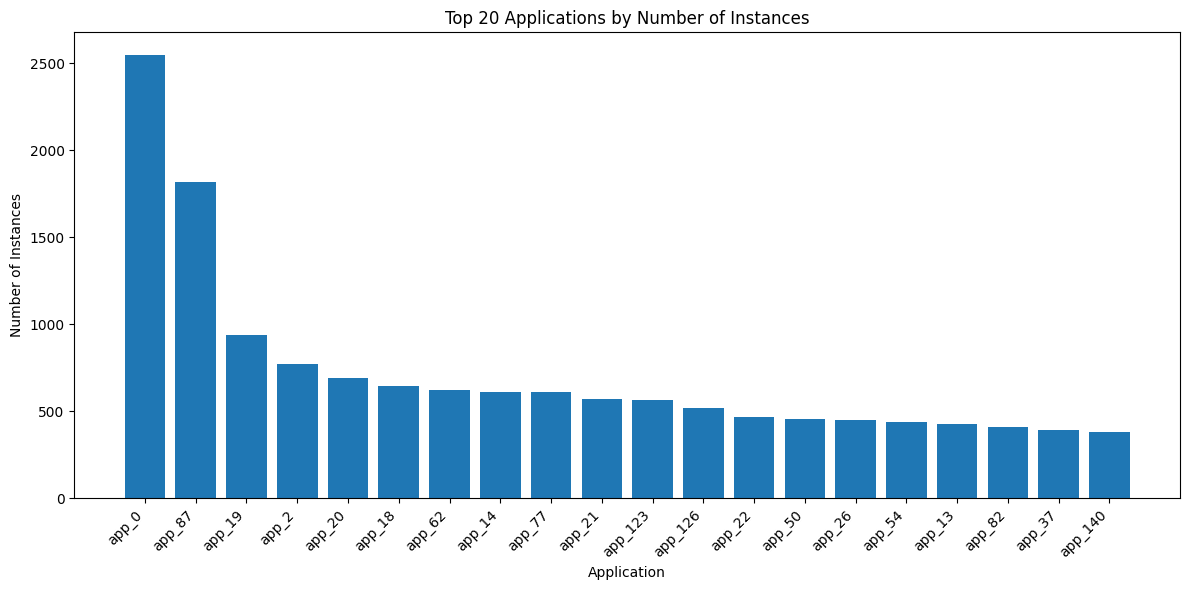

In [303]:
app_counts = instances_per_app_df.collect()
app_names = [r["app_name"] for r in app_counts]
instance_counts = [r["instance_count"] for r in app_counts]

data = list(zip(app_names, instance_counts))
data = sorted(data, key=lambda x: x[1], reverse=True)

top_n = 20
top_data = data[:top_n]

top_app_names = [x[0] for x in top_data]
top_instance_counts = [x[1] for x in top_data]

plt.figure(figsize=(12, 6))
plt.bar(top_app_names, top_instance_counts)

plt.title("Top 20 Applications by Number of Instances")
plt.xlabel("Application")
plt.ylabel("Number of Instances")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

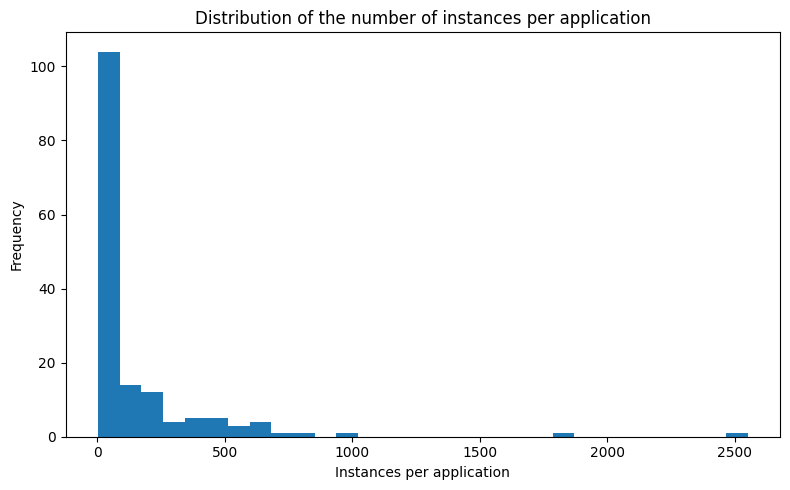

In [304]:
plt.figure(figsize=(8, 5))
plt.hist(instance_counts, bins=min(30, max(5, len(instance_counts))))
plt.title("Distribution of the number of instances per application")
plt.xlabel("Instances per application")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


### Part 1.3, Total CPU and GPU requested by application


In [305]:
resources_by_app_df = (
    clean_df
    .groupBy("app_name")
    .agg(
        F.sum("cpu_request").alias("total_cpu_request"),
        F.sum("gpu_request").alias("total_gpu_request")
    )
)

top10_total_cpu_df = resources_by_app_df.orderBy(F.desc("total_cpu_request"), F.asc("app_name")).limit(10)
top10_total_gpu_df = resources_by_app_df.orderBy(F.desc("total_gpu_request"), F.asc("app_name")).limit(10)

print("Top 10 applications by total CPU request")
top10_total_cpu_df.show(truncate=False)

print("Top 10 applications by total GPU request")
top10_total_gpu_df.show(truncate=False)


Top 10 applications by total CPU request
+--------+-----------------+-----------------+
|app_name|total_cpu_request|total_gpu_request|
+--------+-----------------+-----------------+
|app_87  |112984.0         |59.0             |
|app_0   |98688.0          |660.0            |
|app_19  |62664.0          |257.0            |
|app_35  |48536.0          |43.0             |
|app_2   |45624.0          |71.0             |
|app_18  |43832.0          |163.0            |
|app_21  |39224.0          |175.0            |
|app_77  |35224.0          |67.0             |
|app_13  |34064.0          |82.0             |
|app_126 |33708.0          |188.0            |
+--------+-----------------+-----------------+

Top 10 applications by total GPU request
+--------+-----------------+-----------------+
|app_name|total_cpu_request|total_gpu_request|
+--------+-----------------+-----------------+
|app_0   |98688.0          |660.0            |
|app_20  |22888.0          |381.0            |
|app_62  |18504.0       

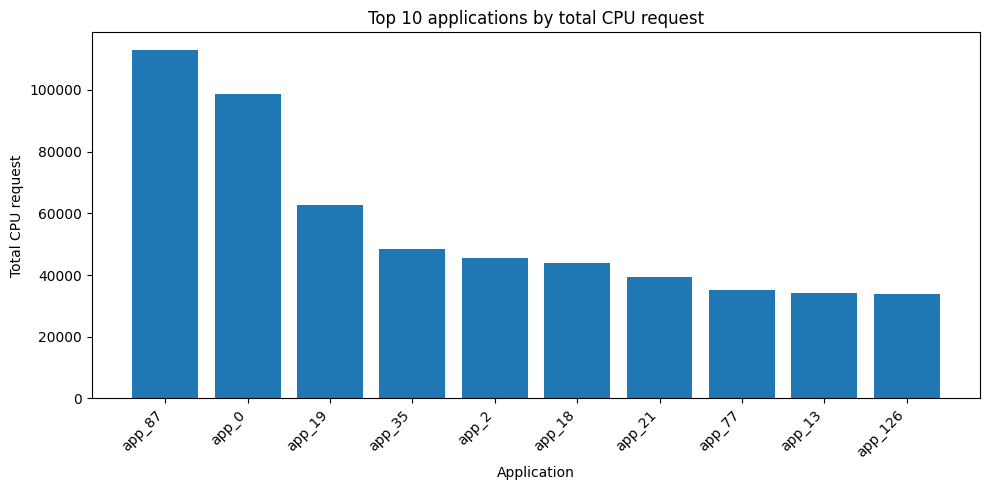

In [306]:
rows = top10_total_cpu_df.collect()
labels = [r["app_name"] for r in rows]
values = [float(r["total_cpu_request"] or 0) for r in rows]

plt.figure(figsize=(10, 5))
plt.bar(labels, values)
plt.title("Top 10 applications by total CPU request")
plt.xlabel("Application")
plt.ylabel("Total CPU request")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


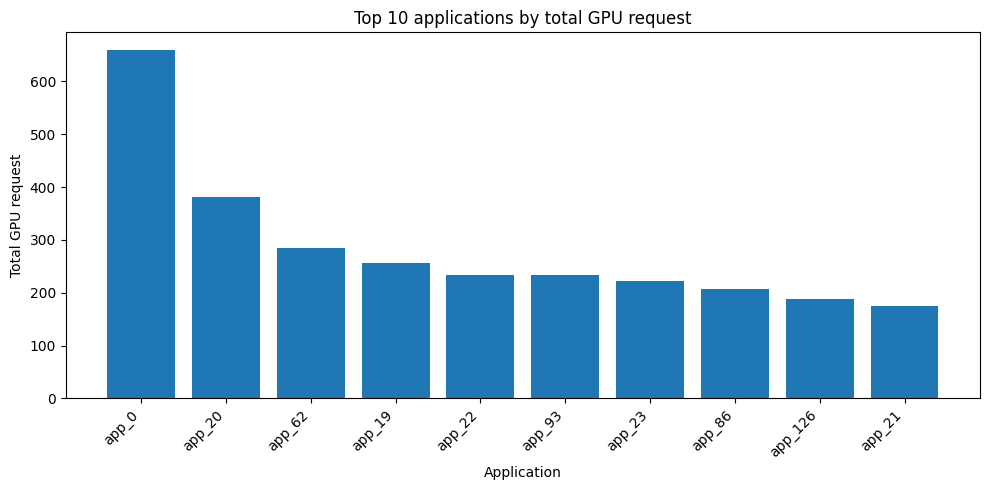

In [307]:
rows = top10_total_gpu_df.collect()
labels = [r["app_name"] for r in rows]
values = [float(r["total_gpu_request"] or 0) for r in rows]

plt.figure(figsize=(10, 5))
plt.bar(labels, values)
plt.title("Top 10 applications by total GPU request")
plt.xlabel("Application")
plt.ylabel("Total GPU request")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [308]:
cpu_top_apps = [r["app_name"] for r in top10_total_cpu_df.collect()]
gpu_top_apps = [r["app_name"] for r in top10_total_gpu_df.collect()]

cpu_only = sorted(set(cpu_top_apps) - set(gpu_top_apps))
gpu_only = sorted(set(gpu_top_apps) - set(cpu_top_apps))
overlap = sorted(set(cpu_top_apps) & set(gpu_top_apps))

print("Overlap between CPU and GPU top-10:", overlap)
print("Only in CPU top-10:", cpu_only)
print("Only in GPU top-10:", gpu_only)


Overlap between CPU and GPU top-10: ['app_0', 'app_126', 'app_19', 'app_21']
Only in CPU top-10: ['app_13', 'app_18', 'app_2', 'app_35', 'app_77', 'app_87']
Only in GPU top-10: ['app_20', 'app_22', 'app_23', 'app_62', 'app_86', 'app_93']


### Part 1.4, Average per-instance resource requests by application

In [309]:
avg_resources_by_app_df = (
    clean_df
    .groupBy("app_name")
    .agg(
        F.avg("cpu_request").alias("avg_cpu_request"),
        F.avg("gpu_request").alias("avg_gpu_request"),
        F.avg("rdma_request").alias("avg_rdma_request"),
        F.avg("memory_request").alias("avg_memory_request"),
        F.avg("disk_request").alias("avg_disk_request")
    )
)

avg_resources_by_app_df.show(20, truncate=False)


+--------+------------------+-------------------+------------------+------------------+------------------+
|app_name|avg_cpu_request   |avg_gpu_request    |avg_rdma_request  |avg_memory_request|avg_disk_request  |
+--------+------------------+-------------------+------------------+------------------+------------------+
|app_72  |14.666666666666666|0.8333333333333334 |21.0              |73.33333333333333 |138.83333333333334|
|app_21  |68.93497363796133 |0.30755711775043937|23.759226713532513|337.2934973637961 |309.32337434094904|
|app_32  |36.22641509433962 |0.6792452830188679 |33.339622641509436|181.1320754716981 |224.52830188679246|
|app_141 |31.846153846153847|0.40384615384615385|10.692307692307692|195.0             |272.4230769230769 |
|app_58  |51.55555555555556 |0.2222222222222222 |6.333333333333333 |257.77777777777777|217.22222222222223|
|app_86  |16.457142857142856|0.8489795918367347 |21.375510204081632|86.81632653061224 |182.53061224489795|
|app_150 |45.333333333333336|0.333333

In [310]:
resource_metrics = [
    ("avg_cpu_request", "Average CPU request per instance"),
    ("avg_gpu_request", "Average GPU request per instance"),
    ("avg_rdma_request", "Average RDMA request per instance"),
    ("avg_memory_request", "Average memory request per instance"),
    ("avg_disk_request", "Average disk request per instance"),
]

for metric, title in resource_metrics:
    top10_df = avg_resources_by_app_df.orderBy(F.desc(metric), F.asc("app_name")).limit(10)
    print(f"Top 10 applications by {metric}")
    top10_df.show(truncate=False)


Top 10 applications by avg_cpu_request
+--------+------------------+-------------------+------------------+------------------+------------------+
|app_name|avg_cpu_request   |avg_gpu_request    |avg_rdma_request  |avg_memory_request|avg_disk_request  |
+--------+------------------+-------------------+------------------+------------------+------------------+
|app_45  |175.27272727272728|0.09090909090909091|48.63636363636363 |876.3636363636364 |324.54545454545456|
|app_122 |171.55555555555554|0.1111111111111111 |48.111111111111114|857.7777777777778 |321.1111111111111 |
|app_35  |165.08843537414967|0.14625850340136054|47.197278911564624|825.4421768707483 |314.421768707483  |
|app_92  |161.33333333333334|0.16666666666666666|46.666666666666664|806.6666666666666 |310.0             |
|app_44  |147.58620689655172|0.2413793103448276 |44.724137931034484|737.9310344827586 |297.58620689655174|
|app_38  |140.72131147540983|0.2786885245901639 |43.75409836065574 |703.6065573770492 |292.62295081967216

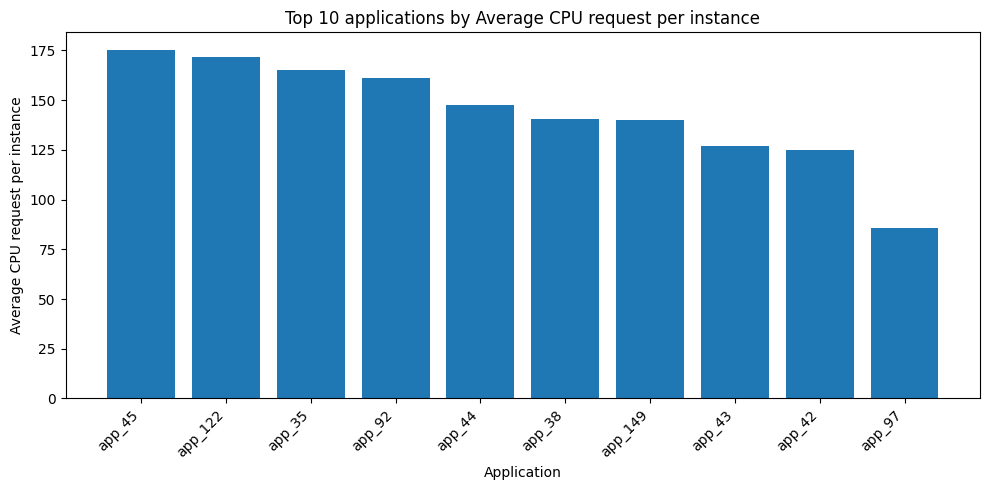

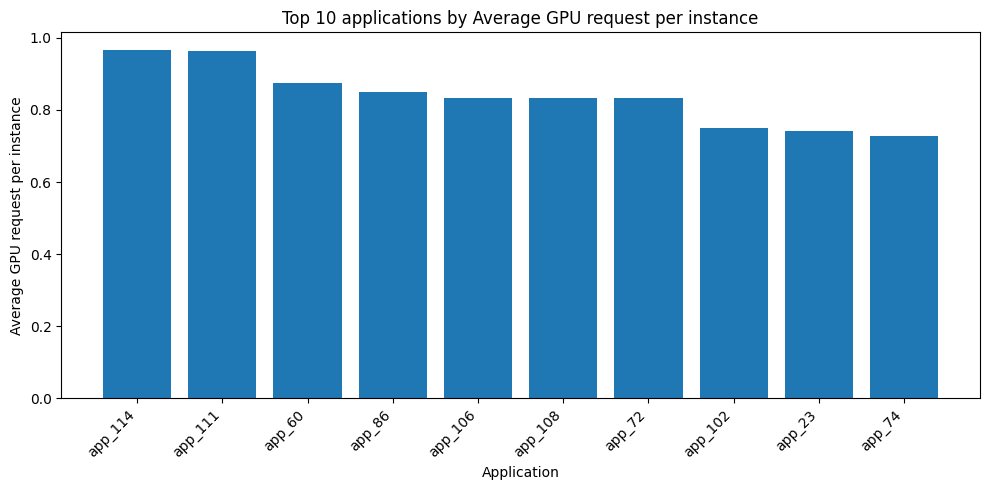

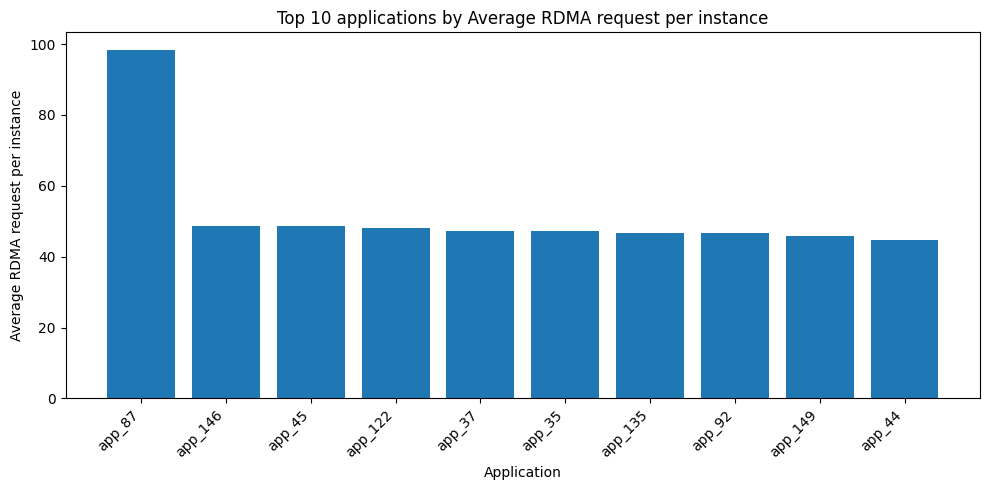

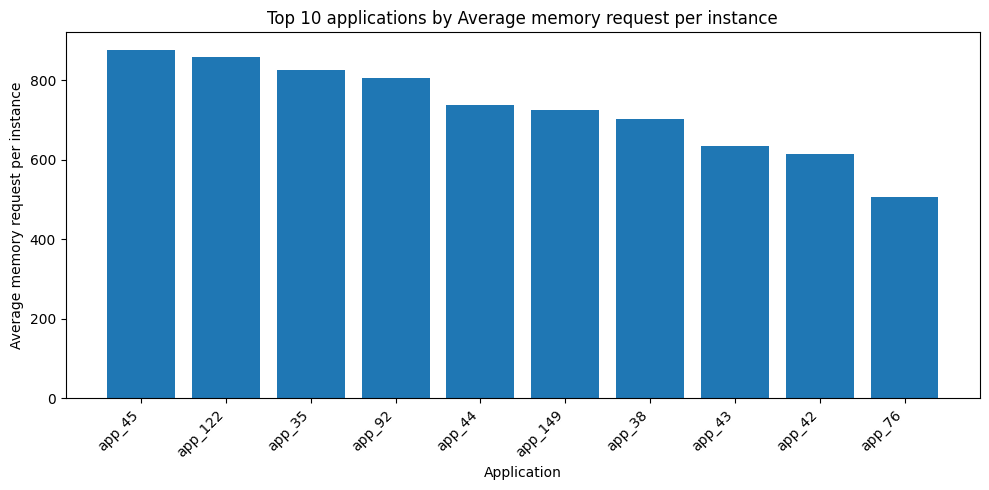

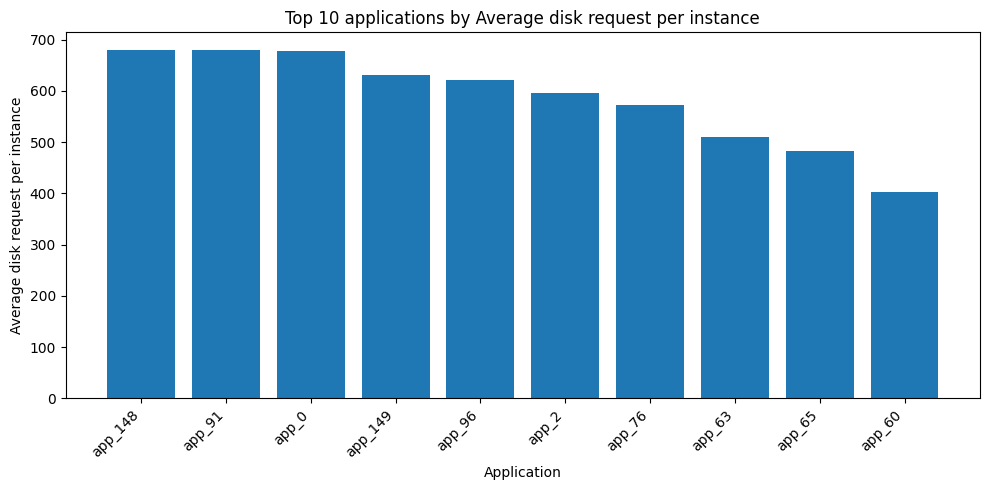

In [311]:
for metric, title in resource_metrics:
    top10_df = avg_resources_by_app_df.orderBy(F.desc(metric), F.asc("app_name")).limit(10)
    rows = top10_df.collect()
    labels = [r["app_name"] for r in rows]
    values = [float(r[metric] or 0) for r in rows]

    plt.figure(figsize=(10, 5))
    plt.bar(labels, values)
    plt.title(f"Top 10 applications by {title}")
    plt.xlabel("Application")
    plt.ylabel(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


In [312]:
rankings = {}
for metric, _ in resource_metrics:
    rankings[metric] = [r["app_name"] for r in avg_resources_by_app_df.orderBy(F.desc(metric), F.asc("app_name")).limit(10).collect()]

for metric, apps in rankings.items():
    print(metric, apps)


avg_cpu_request ['app_45', 'app_122', 'app_35', 'app_92', 'app_44', 'app_38', 'app_149', 'app_43', 'app_42', 'app_97']
avg_gpu_request ['app_114', 'app_111', 'app_60', 'app_86', 'app_106', 'app_108', 'app_72', 'app_102', 'app_23', 'app_74']
avg_rdma_request ['app_87', 'app_146', 'app_45', 'app_122', 'app_37', 'app_35', 'app_135', 'app_92', 'app_149', 'app_44']
avg_memory_request ['app_45', 'app_122', 'app_35', 'app_92', 'app_44', 'app_149', 'app_38', 'app_43', 'app_42', 'app_76']
avg_disk_request ['app_148', 'app_91', 'app_0', 'app_149', 'app_96', 'app_2', 'app_76', 'app_63', 'app_65', 'app_60']


# Part 2


### Part 2.1, Instance lifespan


In [313]:
valid_lifespan_df = (
    clean_df
    .where(F.col("creation_time").isNotNull() & F.col("deletion_time").isNotNull())
    .where(F.col("deletion_time") >= F.col("creation_time"))
    .withColumn(
        "lifespan_hours",
        (F.col("deletion_time").cast("long") - F.col("creation_time").cast("long")) / F.lit(3600.0)
    )
)

print("Number of instances with valid creation and deletion timestamps:", valid_lifespan_df.count())
valid_lifespan_df.select("instance_sn", "role", "app_name", "creation_time", "deletion_time", "lifespan_hours").show(10, truncate=False)


Number of instances with valid creation and deletion timestamps: 11642
+-------------+----+--------+------------------+------------------+-------------------+
|instance_sn  |role|app_name|creation_time     |deletion_time     |lifespan_hours     |
+-------------+----+--------+------------------+------------------+-------------------+
|instance_7281|CN  |app_88  |610.0             |91730.0           |25.31111111111111  |
|instance_7294|CN  |app_28  |2417.0            |561361.0          |155.26222222222222 |
|instance_7296|CN  |app_38  |5687.0            |5813.0            |0.035              |
|instance_7299|CN  |app_0   |3835.0000000000005|4789.0            |0.265              |
|instance_7300|HN  |app_0   |3973.0000000000005|5647.0            |0.465              |
|instance_7301|HN  |app_0   |3974.0000000000005|5658.0            |0.4677777777777778 |
|instance_7302|HN  |app_0   |4012.0000000000005|5965.0            |0.5425             |
|instance_7312|CN  |app_89  |6222.0            |8

In [314]:
result = valid_lifespan_df.select(
    (
        F.max(F.col("deletion_time").cast("double")) -
        F.min(F.col("creation_time").cast("double"))
    ) / F.lit(3600.0)
).first()[0]

if result is not None:
    print(f"Time in hours at which all instances would have been deleted: {result:.3f}")
else:
    print("Could not compute lifecycle")

Time in hours at which all instances would have been deleted: 743.499


In [315]:
top10_lifespan_df = (
    valid_lifespan_df
    .select("instance_sn", "role", "app_name", "lifespan_hours")
    .orderBy(F.desc("lifespan_hours"), F.asc("instance_sn"))
    .limit(10)
)

top10_lifespan_df.show(truncate=False)


+-------------+----+--------+------------------+
|instance_sn  |role|app_name|lifespan_hours    |
+-------------+----+--------+------------------+
|instance_8001|CN  |app_91  |684.0080555555555 |
|instance_8299|CN  |app_91  |667.4947222222222 |
|instance_7959|CN  |app_91  |665.5275          |
|instance_8124|CN  |app_19  |624.4813888888889 |
|instance_7342|CN  |app_22  |616.6091666666666 |
|instance_7686|CN  |app_62  |605.6480555555555 |
|instance_7957|CN  |app_37  |599.6938888888889 |
|instance_7955|CN  |app_0   |570.0116666666667 |
|instance_7731|CN  |app_54  |478.75111111111113|
|instance_7884|CN  |app_35  |464.5963888888889 |
+-------------+----+--------+------------------+



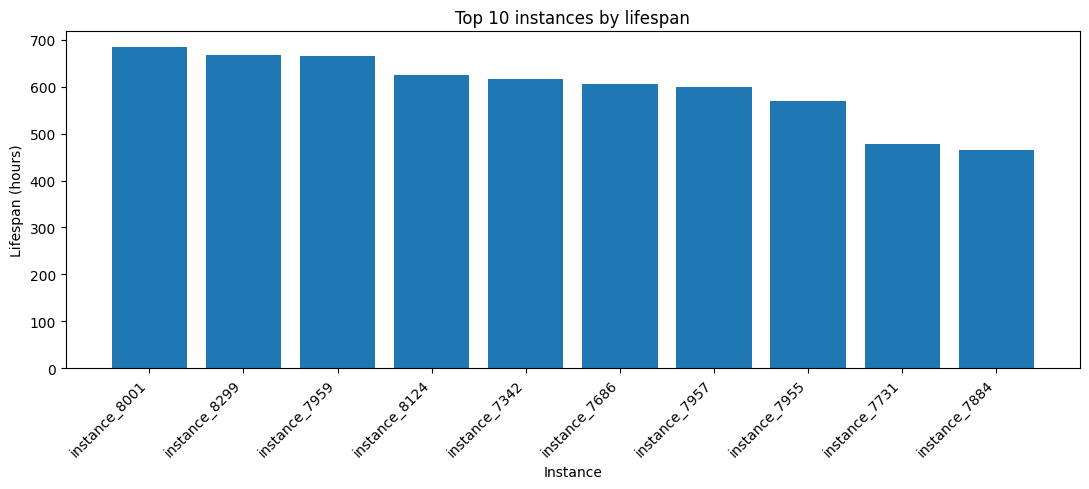

In [316]:
rows = top10_lifespan_df.collect()
labels = [r["instance_sn"] for r in rows]
values = [float(r["lifespan_hours"] or 0) for r in rows]

plt.figure(figsize=(11, 5))
plt.bar(labels, values)
plt.title("Top 10 instances by lifespan")
plt.xlabel("Instance")
plt.ylabel("Lifespan (hours)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [317]:
anchor = valid_lifespan_df.select(
    F.min(F.col("creation_time").cast("double")).alias("min_creation_time")
).first()["min_creation_time"]

active_by_hour_df = (
    valid_lifespan_df
    .withColumn(
        "start_hour",
        F.floor(
            (F.col("creation_time").cast("double") - F.lit(anchor)) / F.lit(3600.0)
        ).cast("int")
    )
    .withColumn(
        "end_hour",
        F.floor(
            (F.col("deletion_time").cast("double") - F.lit(anchor)) / F.lit(3600.0)
        ).cast("int")
    )
    .withColumn(
        "hour",
        F.explode(F.sequence(F.col("start_hour"), F.col("end_hour")))
    )
    .groupBy("hour")
    .count()
    .withColumnRenamed("count", "active_instances")
    .orderBy("hour")
)

active_by_hour_df.show(30, truncate=False)

+----+----------------+
|hour|active_instances|
+----+----------------+
|0   |6               |
|1   |8               |
|2   |4               |
|3   |6               |
|4   |15              |
|5   |17              |
|6   |18              |
|7   |20              |
|8   |29              |
|9   |31              |
|10  |48              |
|11  |53              |
|12  |64              |
|13  |56              |
|14  |52              |
|15  |56              |
|16  |55              |
|17  |56              |
|18  |56              |
|19  |50              |
|20  |49              |
|21  |49              |
|22  |45              |
|23  |48              |
|24  |43              |
|25  |41              |
|26  |34              |
|27  |32              |
|28  |31              |
|29  |35              |
+----+----------------+
only showing top 30 rows



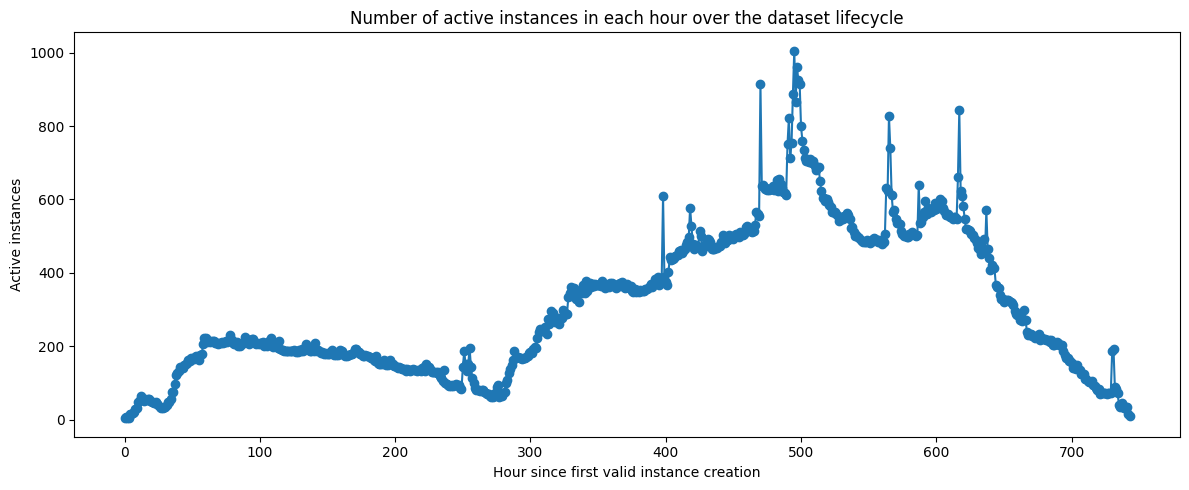

In [318]:
rows = active_by_hour_df.collect()
hours = [r["hour"] for r in rows]
active_counts = [r["active_instances"] for r in rows]

plt.figure(figsize=(12, 5))
plt.plot(hours, active_counts, marker="o")
plt.title("Number of active instances in each hour over the dataset lifecycle")
plt.xlabel("Hour since first valid instance creation")
plt.ylabel("Active instances")
plt.tight_layout()
plt.show()


### Part 2.2, CPU-to-GPU request ratio

In [319]:
ratio_df = (
    clean_df
    .withColumn(
        "effective_gpu_request",
        F.when(F.col("gpu_request").isNull() | (F.col("gpu_request") <= 0), F.lit(1.0)).otherwise(F.col("gpu_request"))
    )
    .withColumn("cpu_to_gpu_ratio", F.col("cpu_request") / F.col("effective_gpu_request"))
)

ratio_df.select("instance_sn", "role", "app_name", "cpu_request", "gpu_request", "effective_gpu_request", "cpu_to_gpu_ratio").show(10, truncate=False)


+-----------+----+--------+-----------+-----------+---------------------+----------------+
|instance_sn|role|app_name|cpu_request|gpu_request|effective_gpu_request|cpu_to_gpu_ratio|
+-----------+----+--------+-----------+-----------+---------------------+----------------+
|instance_0 |HN  |app_0   |12.0       |1.0        |1.0                  |12.0            |
|instance_1 |HN  |app_0   |12.0       |1.0        |1.0                  |12.0            |
|instance_2 |HN  |app_0   |12.0       |1.0        |1.0                  |12.0            |
|instance_3 |HN  |app_0   |12.0       |1.0        |1.0                  |12.0            |
|instance_4 |HN  |app_0   |12.0       |1.0        |1.0                  |12.0            |
|instance_5 |HN  |app_0   |12.0       |1.0        |1.0                  |12.0            |
|instance_6 |HN  |app_0   |12.0       |1.0        |1.0                  |12.0            |
|instance_7 |HN  |app_0   |12.0       |1.0        |1.0                  |12.0            |

In [320]:
top10_ratio_df = (
    ratio_df
    .select("instance_sn", "role", "app_name", "cpu_request", "gpu_request", "cpu_to_gpu_ratio")
    .orderBy(F.desc("cpu_to_gpu_ratio"), F.asc("instance_sn"))
    .limit(10)
)

top10_ratio_df.show(truncate=False)

+--------------+----+--------+-----------+-----------+----------------+
|instance_sn   |role|app_name|cpu_request|gpu_request|cpu_to_gpu_ratio|
+--------------+----+--------+-----------+-----------+----------------+
|instance_10035|CN  |app_35  |192.0      |0.0        |192.0           |
|instance_10093|CN  |app_38  |192.0      |0.0        |192.0           |
|instance_10095|CN  |app_44  |192.0      |0.0        |192.0           |
|instance_10102|CN  |app_35  |192.0      |0.0        |192.0           |
|instance_10144|CN  |app_42  |192.0      |0.0        |192.0           |
|instance_10145|CN  |app_44  |192.0      |0.0        |192.0           |
|instance_10149|CN  |app_35  |192.0      |0.0        |192.0           |
|instance_10152|CN  |app_35  |192.0      |0.0        |192.0           |
|instance_10160|CN  |app_44  |192.0      |0.0        |192.0           |
|instance_10169|CN  |app_44  |192.0      |0.0        |192.0           |
+--------------+----+--------+-----------+-----------+----------

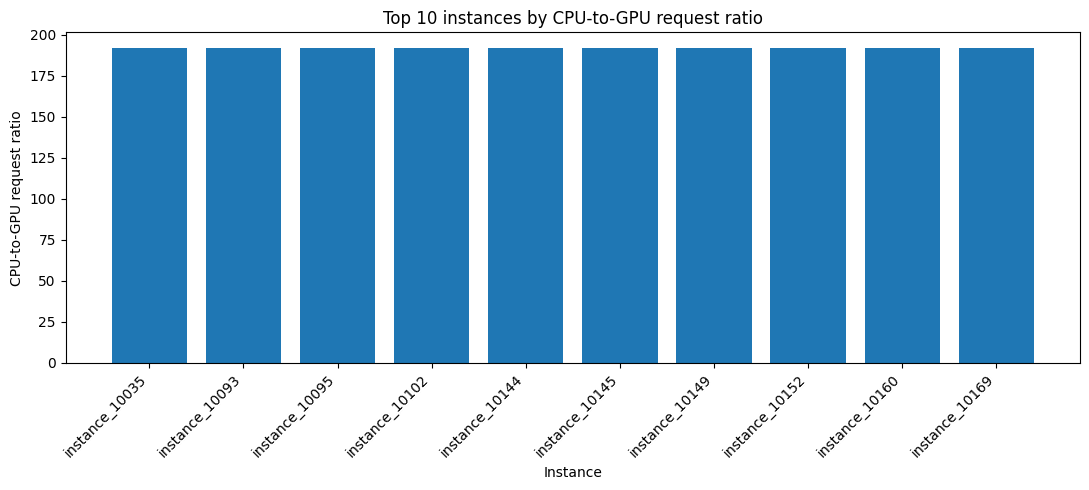

In [321]:
rows = top10_ratio_df.collect()
labels = [r["instance_sn"] for r in rows]
values = [float(r["cpu_to_gpu_ratio"] or 0) for r in rows]

plt.figure(figsize=(11, 5))
plt.bar(labels, values)
plt.title("Top 10 instances by CPU-to-GPU request ratio")
plt.xlabel("Instance")
plt.ylabel("CPU-to-GPU request ratio")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [322]:
ratio_non_null_df = ratio_df.where(F.col("cpu_to_gpu_ratio").isNotNull())

ratio_count = ratio_non_null_df.count()
ratio_window = Window.orderBy(F.asc("cpu_to_gpu_ratio"), F.asc("instance_sn"))

cdf_df = (
    ratio_non_null_df
    .select("instance_sn", "cpu_to_gpu_ratio")
    .withColumn("rank", F.row_number().over(ratio_window))
    .withColumn("cdf", F.col("rank") / F.lit(ratio_count))
    .orderBy("cpu_to_gpu_ratio", "instance_sn")
)

cdf_df.show(20, truncate=False)


+--------------+----------------+----+---------------------+
|instance_sn   |cpu_to_gpu_ratio|rank|cdf                  |
+--------------+----------------+----+---------------------+
|instance_10516|2.0             |1   |4.1891835281303674E-5|
|instance_10517|2.0             |2   |8.378367056260735E-5 |
|instance_10518|2.0             |3   |1.2567550584391103E-4|
|instance_10519|2.0             |4   |1.675673411252147E-4 |
|instance_10520|2.0             |5   |2.0945917640651838E-4|
|instance_10521|2.0             |6   |2.5135101168782207E-4|
|instance_10522|2.0             |7   |2.9324284696912573E-4|
|instance_10523|2.0             |8   |3.351346822504294E-4 |
|instance_10524|2.0             |9   |3.7702651753173305E-4|
|instance_10525|2.0             |10  |4.1891835281303676E-4|
|instance_10526|2.0             |11  |4.608101880943404E-4 |
|instance_10527|2.0             |12  |5.027020233756441E-4 |
|instance_10528|2.0             |13  |5.445938586569477E-4 |
|instance_10529|2.0     

26/04/16 16:32:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/16 16:32:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/16 16:32:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/16 16:32:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/16 16:32:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


26/04/16 16:32:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/16 16:32:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/16 16:32:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/16 16:32:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


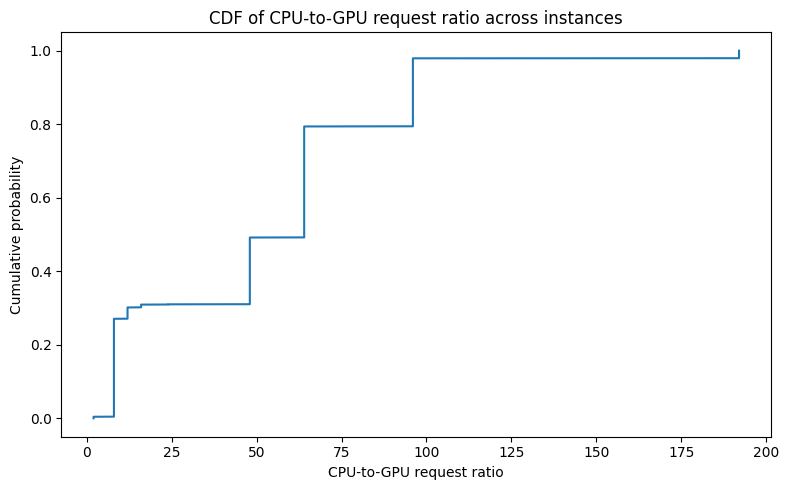

In [323]:
rows = cdf_df.select("cpu_to_gpu_ratio", "cdf").collect()
x = [float(r["cpu_to_gpu_ratio"]) for r in rows]
y = [float(r["cdf"]) for r in rows]

plt.figure(figsize=(8, 5))
plt.plot(x, y)
plt.title("CDF of CPU-to-GPU request ratio across instances")
plt.xlabel("CPU-to-GPU request ratio")
plt.ylabel("Cumulative probability")
plt.tight_layout()
plt.show()


In [324]:
print("PART 1 SUMMARY")
print("- Total rows:", total_instances)
print("- Distinct applications:", num_apps)
print("- Roles present:", [r["role"] for r in roles_df.collect()])
print()
print("PART 2 SUMMARY")
print("- Valid lifespan rows:", valid_lifespan_df.count())
print("- Ratio rows:", ratio_count)


PART 1 SUMMARY
- Total rows: 23871
- Distinct applications: 156
- Roles present: ['CN', 'HN']

PART 2 SUMMARY
- Valid lifespan rows: 11642
- Ratio rows: 23871


# Part3

### Part 3.1

In [325]:
role_window = Window.partitionBy("role").orderBy(F.desc("lifespan_hours"), F.asc("instance_sn"))

top10_lifespan_by_role_df = (
    valid_lifespan_df
    .select("instance_sn", "role", "app_name", "lifespan_hours")
    .withColumn("rank_within_role", F.row_number().over(role_window))
    .where(F.col("rank_within_role") <= 10)
    .orderBy("role", "rank_within_role")
)

top10_lifespan_by_role_df.show(30, truncate=False)

+--------------+----+--------+------------------+----------------+
|instance_sn   |role|app_name|lifespan_hours    |rank_within_role|
+--------------+----+--------+------------------+----------------+
|instance_8001 |CN  |app_91  |684.0080555555555 |1               |
|instance_8299 |CN  |app_91  |667.4947222222222 |2               |
|instance_7959 |CN  |app_91  |665.5275          |3               |
|instance_8124 |CN  |app_19  |624.4813888888889 |4               |
|instance_7342 |CN  |app_22  |616.6091666666666 |5               |
|instance_7686 |CN  |app_62  |605.6480555555555 |6               |
|instance_7957 |CN  |app_37  |599.6938888888889 |7               |
|instance_7955 |CN  |app_0   |570.0116666666667 |8               |
|instance_7731 |CN  |app_54  |478.75111111111113|9               |
|instance_7884 |CN  |app_35  |464.5963888888889 |10              |
|instance_12210|HN  |app_100 |402.95444444444445|1               |
|instance_11691|HN  |app_112 |401.9475          |2            

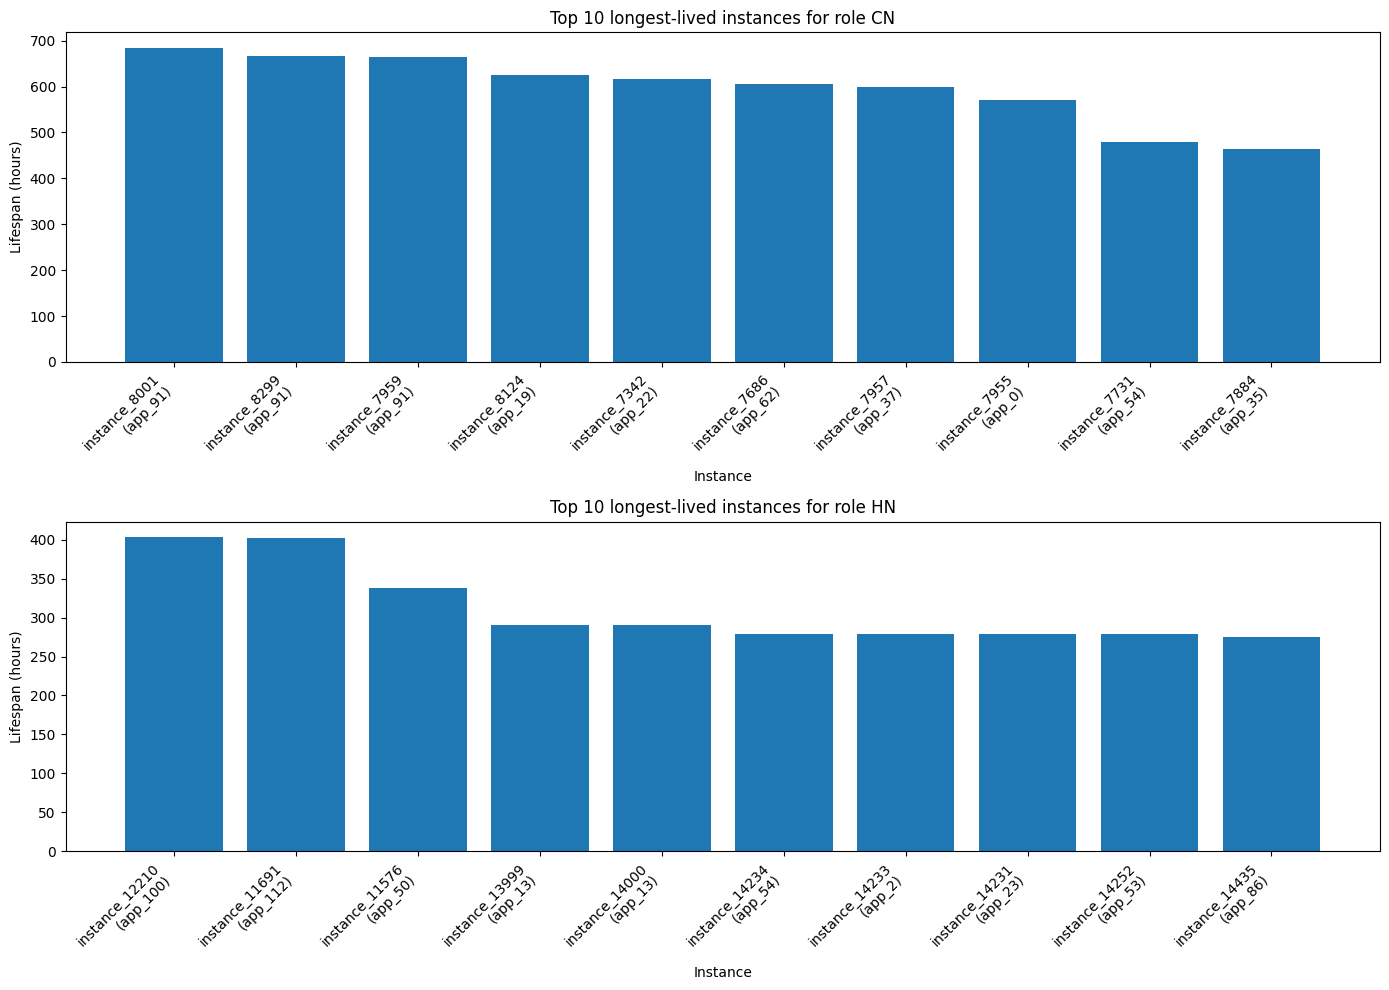

In [326]:
import matplotlib.pyplot as plt

rows = top10_lifespan_by_role_df.collect()

role_to_points = {}
for r in rows:
    role = r["role"]
    label = f'{r["instance_sn"]}\n({r["app_name"]})'
    value = r["lifespan_hours"]
    role_to_points.setdefault(role, []).append((label, value))

roles_sorted = sorted(role_to_points.keys())

fig, axes = plt.subplots(len(roles_sorted), 1, figsize=(14, 5 * max(1, len(roles_sorted))))
if len(roles_sorted) == 1:
    axes = [axes]

for ax, role in zip(axes, roles_sorted):
    labels = [x[0] for x in role_to_points[role]]
    values = [x[1] for x in role_to_points[role]]

    ax.bar(range(len(labels)), values)
    ax.set_title(f"Top 10 longest-lived instances for role {role}")
    ax.set_xlabel("Instance")
    ax.set_ylabel("Lifespan (hours)")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [ ]:
role_anchor = valid_lifespan_df.select(
    F.min(F.col("creation_time").cast("double")).alias("min_creation_time")
).first()["min_creation_time"]

active_by_role_hour_df = (
    valid_lifespan_df
    .withColumn(
        "start_hour",
        F.floor(
            (F.col("creation_time").cast("double") - F.lit(role_anchor)) / F.lit(3600.0)
        ).cast("int")
    )
    .withColumn(
        "end_hour",
        F.floor(
            (F.col("deletion_time").cast("double") - F.lit(role_anchor)) / F.lit(3600.0)
        ).cast("int")
    )
    .withColumn("hour", F.explode(F.sequence(F.col("start_hour"), F.col("end_hour"))))
    .groupBy("hour", "role")
    .count()
    .withColumnRenamed("count", "active_instances")
    .orderBy("hour", "role")
)

active_by_role_hour_df.show(30, truncate=False)

+----+----+----------------+
|hour|role|active_instances|
+----+----+----------------+
|0   |CN  |3               |
|0   |HN  |3               |
|1   |CN  |5               |
|1   |HN  |3               |
|2   |CN  |4               |
|3   |CN  |5               |
|3   |HN  |1               |
|4   |CN  |12              |
|4   |HN  |3               |
|5   |CN  |15              |
|5   |HN  |2               |
|6   |CN  |16              |
|6   |HN  |2               |
|7   |CN  |18              |
|7   |HN  |2               |
|8   |CN  |25              |
|8   |HN  |4               |
|9   |CN  |27              |
|9   |HN  |4               |
|10  |CN  |43              |
|10  |HN  |5               |
|11  |CN  |48              |
|11  |HN  |5               |
|12  |CN  |58              |
|12  |HN  |6               |
|13  |CN  |52              |
|13  |HN  |4               |
|14  |CN  |48              |
|14  |HN  |4               |
|15  |CN  |50              |
+----+----+----------------+
only showing t

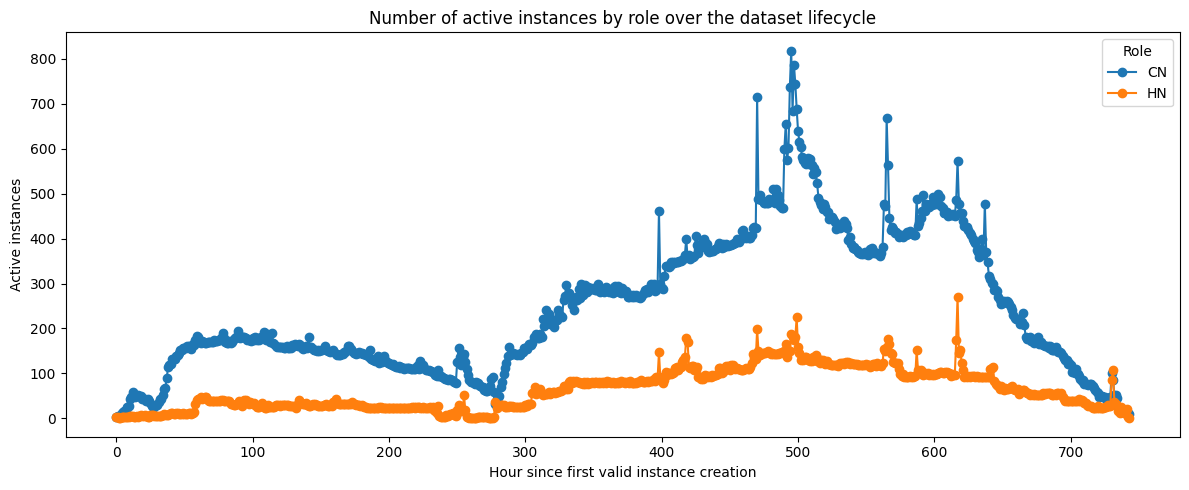

In [328]:
rows = active_by_role_hour_df.collect()

role_series = {}
all_hours = sorted({r["hour"] for r in rows})

for r in rows:
    role_series.setdefault(r["role"], {})[r["hour"]] = r["active_instances"]

plt.figure(figsize=(12, 5))

for role in sorted(role_series.keys()):
    y = [role_series[role].get(h, 0) for h in all_hours]
    plt.plot(all_hours, y, marker="o", label=role)

plt.title("Number of active instances by role over the dataset lifecycle")
plt.xlabel("Hour since first valid instance creation")
plt.ylabel("Active instances")
plt.legend(title="Role")
plt.tight_layout()
plt.show()

In [329]:
role_lifespan_summary_df = (
    valid_lifespan_df
    .groupBy("role")
    .agg(
        F.count("*").alias("instance_count"),
        F.avg("lifespan_hours").alias("avg_lifespan_hours"),
        F.max("lifespan_hours").alias("max_lifespan_hours"),
        F.min("lifespan_hours").alias("min_lifespan_hours")
    )
    .orderBy("role")
)

role_lifespan_summary_df.show(truncate=False)

+----+--------------+------------------+------------------+--------------------+
|role|instance_count|avg_lifespan_hours|max_lifespan_hours|min_lifespan_hours  |
+----+--------------+------------------+------------------+--------------------+
|CN  |8611          |20.311203402624432|684.0080555555555 |8.333333333333334E-4|
|HN  |3031          |14.680010264305814|402.95444444444445|0.0                 |
+----+--------------+------------------+------------------+--------------------+



## Part 3.2

In [330]:
avg_resources_per_app_df = (
    clean_df
    .groupBy("app_name")
    .agg(
        F.avg(F.col("cpu_request").cast("double")).alias("avg_cpu_request"),
        F.avg(F.col("gpu_request").cast("double")).alias("avg_gpu_request"),
        F.avg(F.col("rdma_request").cast("double")).alias("avg_rdma_request"),
        F.avg(F.col("memory_request").cast("double")).alias("avg_memory_request"),
        F.avg(F.col("disk_request").cast("double")).alias("avg_disk_request")
    )
    .orderBy("app_name")
)

avg_resources_per_app_df.show(10, truncate=False)

+--------+------------------+-------------------+------------------+------------------+------------------+
|app_name|avg_cpu_request   |avg_gpu_request    |avg_rdma_request  |avg_memory_request|avg_disk_request  |
+--------+------------------+-------------------+------------------+------------------+------------------+
|app_0   |38.686005488043904|0.2587220697765582 |25.0              |188.9141513132105 |678.2908663269307 |
|app_1   |49.06666666666667 |0.5333333333333333 |13.8              |241.86666666666667|281.06666666666666|
|app_10  |56.888888888888886|0.4444444444444444 |11.666666666666666|280.8888888888889 |179.44444444444446|
|app_100 |36.96551724137931 |0.4827586206896552 |12.586206896551724|173.24137931034483|213.9655172413793 |
|app_101 |26.666666666666668|0.6666666666666666 |17.0              |173.33333333333334|198.07692307692307|
|app_102 |30.0              |0.75               |19.0              |132.0             |191.25            |
|app_103 |44.23529411764706 |0.352941

In [331]:
resource_cols = [
    "avg_cpu_request",
    "avg_gpu_request",
    "avg_rdma_request",
    "avg_memory_request",
    "avg_disk_request"
]

corr_rows = []
for i, c1 in enumerate(resource_cols):
    for j, c2 in enumerate(resource_cols):
        if i <= j:
            corr_value = avg_resources_per_app_df.stat.corr(c1, c2)
            corr_rows.append((c1, c2, corr_value))

correlation_df = spark.createDataFrame(
    corr_rows,
    ["resource_1", "resource_2", "pearson_correlation"]
)

correlation_df.show(30, truncate=False)

+------------------+------------------+--------------------+
|resource_1        |resource_2        |pearson_correlation |
+------------------+------------------+--------------------+
|avg_cpu_request   |avg_cpu_request   |1.0                 |
|avg_cpu_request   |avg_gpu_request   |-0.5822385750875334 |
|avg_cpu_request   |avg_rdma_request  |0.39884175374126224 |
|avg_cpu_request   |avg_memory_request|0.9734833896189815  |
|avg_cpu_request   |avg_disk_request  |0.24056824830675036 |
|avg_gpu_request   |avg_gpu_request   |1.0                 |
|avg_gpu_request   |avg_rdma_request  |0.12079976925520791 |
|avg_gpu_request   |avg_memory_request|-0.5722737210247093 |
|avg_gpu_request   |avg_disk_request  |-0.34766490336192357|
|avg_rdma_request  |avg_rdma_request  |1.0                 |
|avg_rdma_request  |avg_memory_request|0.3947782259121707  |
|avg_rdma_request  |avg_disk_request  |0.14861152223251484 |
|avg_memory_request|avg_memory_request|1.0                 |
|avg_memory_request|avg_

In [ ]:
corr_map = {(c, c): 1.0 for c in resource_cols}

for r in correlation_df.collect():
    c1 = r["resource_1"]
    c2 = r["resource_2"]
    v = r["pearson_correlation"]
    corr_map[(c1, c2)] = v
    corr_map[(c2, c1)] = v

matrix_rows = []
for r1 in resource_cols:
    matrix_rows.append(tuple([r1] + [corr_map[(r1, r2)] for r2 in resource_cols]))

correlation_matrix_df = spark.createDataFrame(
    matrix_rows,
    ["resource"] + resource_cols
)

correlation_matrix_df.show(truncate=False)

+------------------+-------------------+--------------------+-------------------+-------------------+--------------------+
|resource          |avg_cpu_request    |avg_gpu_request     |avg_rdma_request   |avg_memory_request |avg_disk_request    |
+------------------+-------------------+--------------------+-------------------+-------------------+--------------------+
|avg_cpu_request   |1.0                |-0.5822385750875334 |0.39884175374126224|0.9734833896189815 |0.24056824830675036 |
|avg_gpu_request   |-0.5822385750875334|1.0                 |0.12079976925520791|-0.5722737210247093|-0.34766490336192357|
|avg_rdma_request  |0.39884175374126224|0.12079976925520791 |1.0                |0.3947782259121707 |0.14861152223251484 |
|avg_memory_request|0.9734833896189815 |-0.5722737210247093 |0.3947782259121707 |1.0                |0.27884067149225644 |
|avg_disk_request  |0.24056824830675036|-0.34766490336192357|0.14861152223251484|0.27884067149225644|1.0                 |
+---------------

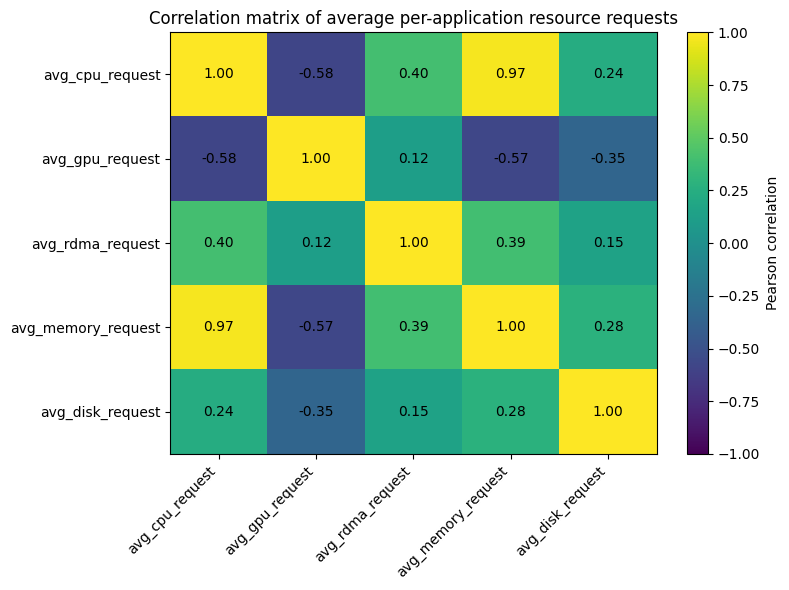

In [333]:
import matplotlib.pyplot as plt

matrix = [[corr_map[(r1, r2)] for r2 in resource_cols] for r1 in resource_cols]

plt.figure(figsize=(8, 6))
img = plt.imshow(matrix, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(img, label="Pearson correlation")

plt.xticks(range(len(resource_cols)), resource_cols, rotation=45, ha="right")
plt.yticks(range(len(resource_cols)), resource_cols)

for i in range(len(resource_cols)):
    for j in range(len(resource_cols)):
        plt.text(j, i, f"{matrix[i][j]:.2f}", ha="center", va="center")

plt.title("Correlation matrix of average per-application resource requests")
plt.tight_layout()
plt.show()

In [ ]:
spark.stop()